

***

# District‑level crop yield prediction using machine learning

**MSc Data Science Project – 7PAM2002-0206-2025**  

**Student:** BUREBOINA VAMSHI  

**SRN:** 24085801  

**GitHub repository:** https://github.com/vamshi-34/Crop_Prediction

## Research problem

The central research question of this project is:

> To what extent can tree‑based machine‑learning models trained solely on APY statistics accurately predict district‑level crop yields in India, and how do they compare with a linear regression baseline?

The notebook implements the full pipeline used to answer this question.

## Dataset overview

The analysis uses the Indian Area, Production and Yield (APY) dataset, where each row corresponds to a combination of state, district, crop, season and crop year. The main columns are:

- **State** – name of the Indian state or union territory.  
- **District** – name of the district within the state.  
- **Crop** – crop name (e.g. rice, wheat, sugarcane, coconut).  
- **Crop_Year** – crop year (e.g. 1997, 2010, 2019).  
- **Season** – cropping season (e.g. Kharif, Rabi, Summer, Whole Year).  
- **Area** – cultivated area in hectares.  
- **Production** – total production in tonnes.  
- **Yield** – derived yield in tonnes per hectare (Production divided by Area).

In the Indian context, **Kharif** refers to the monsoon cropping season, with crops typically sown from **June–July** and harvested around **September–October**, while **Rabi** refers to the before winter season, with crops sown from **October–November** and harvested around **April–May**.

## Notebook objectives

This notebook will:

- Load and clean the raw APY data, including handling missing values and implausible yield outliers.  
- Explore key patterns in yield across seasons, crops, states and years.  
- Encode categorical and numeric features, then train several models (Ridge, Random Forest and HistGradientBoostingRegressor).  
- Refine the tree‑based models, compare their test performance, and interpret feature importance for the best model to understand which factors drive yield predictions, while avoiding target leakage from Production by using Yield as the target and a reduced set of predictors.
***



## 1. Data loading and initial inspection

In this section I load the APY dataset, check basic structure and data types, and confirm that the target variable (Yield) is suitable for supervised regression.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

# Load the dataset (update path if needed)
file_path = "APY.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
display(df.head())

Shape: (345336, 8)

Columns:
 Index(['State', 'District ', 'Crop', 'Crop_Year', 'Season', 'Area ',
       'Production', 'Yield'],
      dtype='object')

Data types:
 State          object
District       object
Crop           object
Crop_Year       int64
Season         object
Area          float64
Production    float64
Yield         float64
dtype: object

First 5 rows:


,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.75


## 2. Basic cleaning and sanity checks

Here I standardise column names, inspect missing values and basic descriptive statistics to understand data quality before modelling.

In [ ]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

print("Columns after stripping whitespace:\n", df.columns)

# Basic info and missing values
print("\nDataFrame info:")
print(df.info())

print("\nMissing values per column:")
print(df.isna().sum())

# Descriptive statistics for numerical columns
print("\nDescriptive statistics (numerical features):")
display(df[["Area", "Production", "Yield"]].describe())

# Unique counts for key categorical variables
for col in ["State", "District", "Crop", "Season", "Crop_Year"]:
    print(f"\n{col} - unique values:", df[col].nunique())

Columns after stripping whitespace:
 Index(['State', 'District', 'Crop', 'Crop_Year', 'Season', 'Area',
       'Production', 'Yield'],
      dtype='object')

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345336 entries, 0 to 345335
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   State       345336 non-null  object 
 1   District    345336 non-null  object 
 2   Crop        345327 non-null  object 
 3   Crop_Year   345336 non-null  int64  
 4   Season      345336 non-null  object 
 5   Area        345336 non-null  float64
 6   Production  340388 non-null  float64
 7   Yield       345336 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 21.1+ MB
None

Missing values per column:
State            0
District         0
Crop             9
Crop_Year        0
Season           0
Area             0
Production    4948
Yield            0
dtype: int64

Descriptive statistics (numerical 

,Area,Production,Yield
count,3.453360e+05,3.403880e+05,345336.000000
mean,1.167147e+04,9.584726e+05,79.423135
std,4.584079e+04,2.153068e+07,916.678396
min,4.000000e-03,0.000000e+00,0.000000
25%,7.400000e+01,8.700000e+01,0.550000
50%,5.320000e+02,7.170000e+02,1.000000
75%,4.112000e+03,7.182000e+03,2.470000
max,8.580100e+06,1.597800e+09,43958.330000



State - unique values: 37

District - unique values: 707

Crop - unique values: 55

Season - unique values: 6

Crop_Year - unique values: 24


2.1 Summary of initial inspection

- 345,336 rows and 8 columns, suitable for supervised learning.
- Categorical: State, District, Crop, Season; numeric: Area, Production, Yield; year: Crop_Year.
- Missing values only in Crop (9) and Production (4,948); Yield has no missing values.
- Area, Production and Yield are highly skewed with very large maxima.
- Yield has realistic central values but extreme upper outliers (up to 43,958 t/ha).

## 3. Handling extreme yields and missing values

I remove rows with missing Crop, non-positive yields, and extreme yield outliers before modelling.

In [ ]:
df_clean = df.copy()

# Drop rows with missing Crop
df_clean = df_clean[df_clean["Crop"].notna()]

# Keep only strictly positive yields
df_clean = df_clean[df_clean["Yield"] > 0]

# Compute crop-specific caps
caps = (
    df_clean.groupby("Crop")["Yield"]
    .quantile(0.999)          # 99.9th percentile per crop
    .clip(upper=200)          # cap at 200 t/ha per crop
)

# Map each row to its crop-specific cap and filter
n_before = len(df_clean)
df_clean = df_clean[
    df_clean["Yield"] <= df_clean["Crop"].map(caps)
]
n_after = len(df_clean)

print(f"\nRows before cap: {n_before:,}")
print(f"Rows after cap:  {n_after:,}")
print(f"Rows removed by crop-specific yield caps: {n_before - n_after:,}")


Rows before cap: 339,236
Rows after cap:  335,997
Rows removed by crop-specific yield caps: 3,239


Extremely large yield values are present in the raw data, so crop‑specific upper caps were applied to remove implausible outliers. Applying a 99.9th percentile cap per crop (with an absolute ceiling of 200 t/ha) removes 3,239 rows, reducing the dataset from 339,236 to 335,997 observations while retaining the vast majority of records.


## 4. Dataset for modelling and EDA

I use the cleaned dataset `df_clean` as the basis for EDA and model training.

### 4.1 Distributions of numerical variables


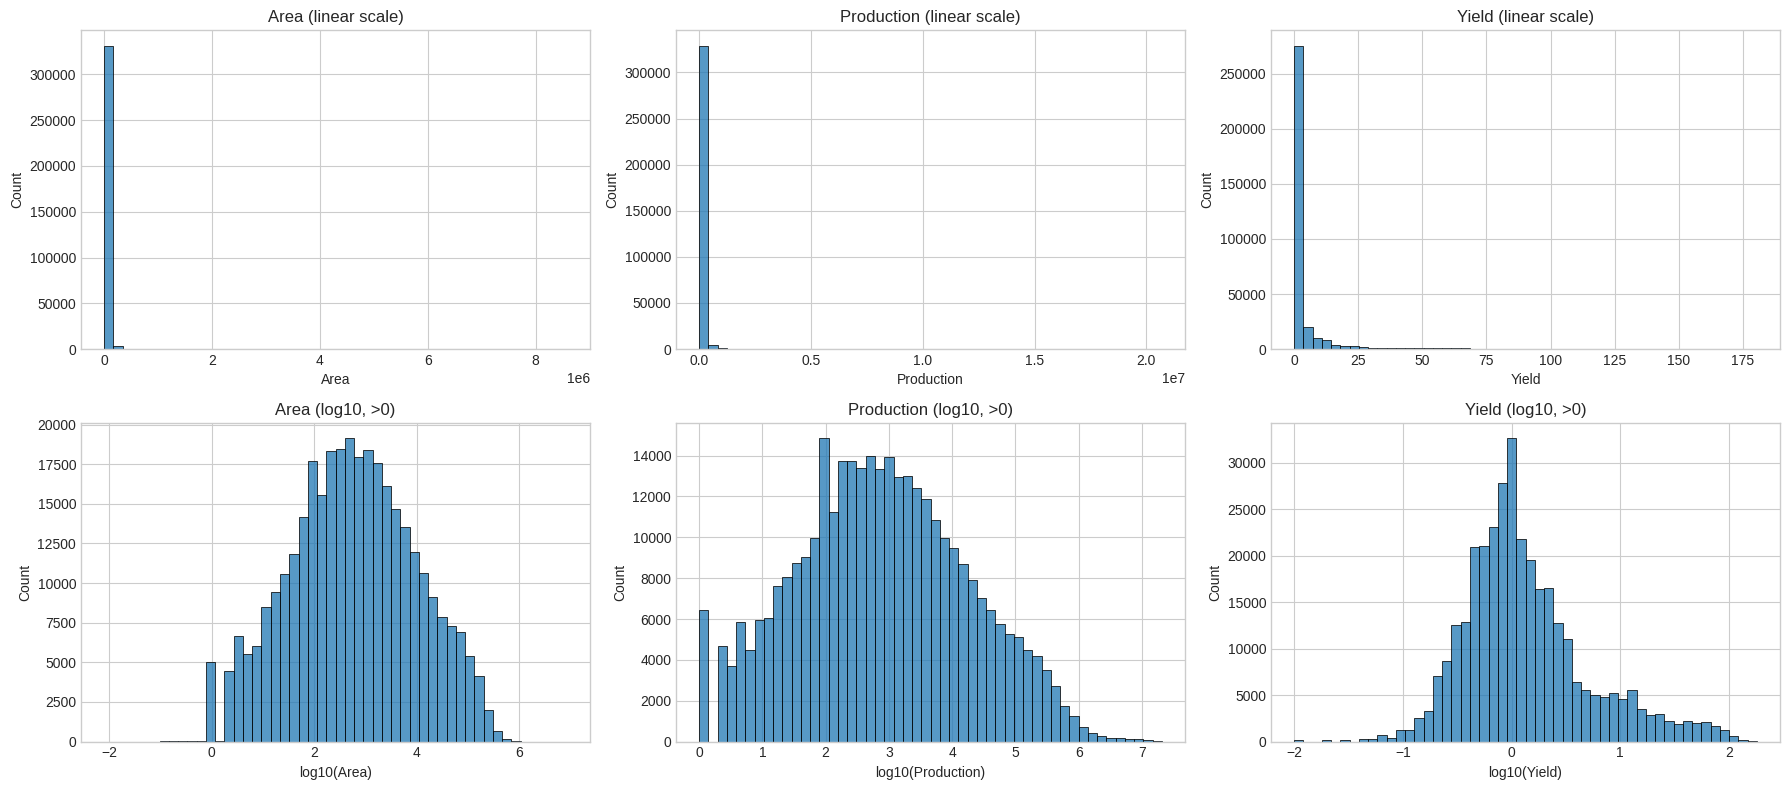

In [ ]:
df_model = df_clean.copy()  # or use your df_model if already defined

num_cols = ["Area", "Production", "Yield"]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, col in enumerate(num_cols):
    # Linear scale histogram
    sns.histplot(df_model[col].dropna(), bins=50, ax=axes[0, i], kde=False)
    axes[0, i].set_title(f"{col} (linear scale)")

    # Log10 histogram for positive values
    positive_vals = df_model[col][df_model[col] > 0]
    sns.histplot(np.log10(positive_vals), bins=50, ax=axes[1, i], kde=False)
    axes[1, i].set_title(f"{col} (log10, >0)")
    axes[1, i].set_xlabel(f"log10({col})")

plt.tight_layout()
plt.show()

On the original scale, Area, Production and Yield are all highly right‑skewed, with most observations at low values and a long tail of large observations. On the log10 scale, Area and Production become close to symmetric, while Yield remains somewhat right‑skewed with a noticeable upper tail, indicating more extreme high‑yield values than for the other variables.



### 4.2 Yield by season

I compare average yield across seasons to see when districts tend to be most productive.

['Autumn     ', 'Kharif     ', 'Rabi       ', 'Summer     ', 'Whole Year ', 'Winter     ']


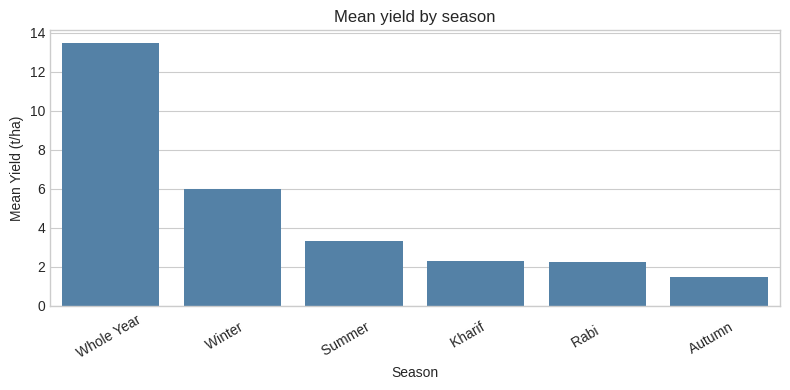

In [ ]:
# Check unique season values first
print(sorted(df_model["Season"].unique()))

season_yield = (
    df_model.groupby("Season")["Yield"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
sns.barplot(x=season_yield.index, y=season_yield.values, color="steelblue")
plt.ylabel("Mean Yield (t/ha)")
plt.xlabel("Season")
plt.title("Mean yield by season")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Whole Year and Winter seasons have the highest mean yields, with Whole Year substantially above all other categories and Winter around 6 t/ha. Summer sits in the middle, while Kharif, Rabi and Autumn show clearly lower average yields, indicating pronounced seasonal differences in productivity.


In [ ]:
df_model = df_clean.copy()

In [ ]:
# After you finish the new crop-specific cap section
df_model = df_clean.copy()
print(df_model.columns)

Index(['State', 'District', 'Crop', 'Crop_Year', 'Season', 'Area',
       'Production', 'Yield'],
      dtype='object')


### 4.3 Yield by crop (top 15)

I examine which crops have the highest and lowest average yields across districts.

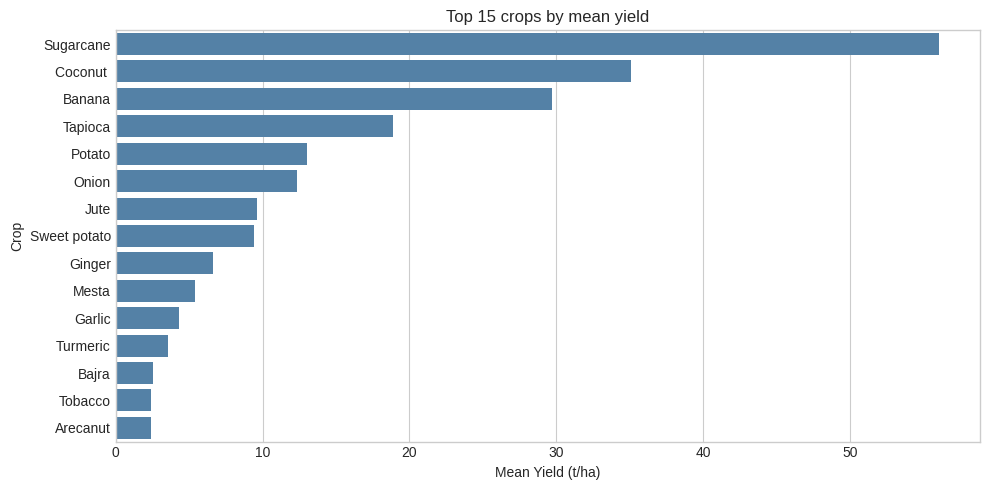

In [ ]:
# Mean yield by crop
crop_yield = (
    df_model.groupby("Crop")["Yield"]
    .mean()
    .sort_values(ascending=False)
)

top_n = 15
top_crops = crop_yield.head(top_n)

plt.figure(figsize=(10, 5))
sns.barplot(
    y=top_crops.index,
    x=top_crops.values,
    color="steelblue"
)
plt.xlabel("Mean Yield (t/ha)")
plt.ylabel("Crop")
plt.title(f"Top {top_n} crops by mean yield")
plt.tight_layout()
plt.show()

Among the top 15 crops by mean yield, Sugarcane stands out with the highest average yield, followed by Coconut, Banana and Tapioca. Several other crops such as Potato, Onion and Jute also show relatively high mean yields compared with most crops in the dataset, indicating substantial differences in typical productivity between crop types.


4.3.1 Normalised yield within crop

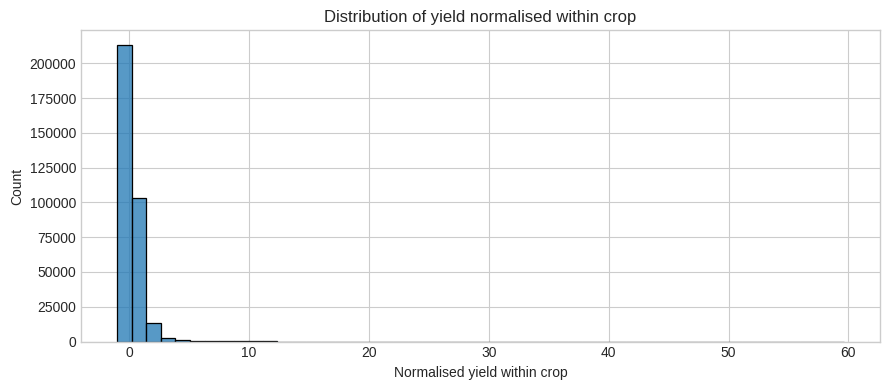

In [ ]:
# Normalise yield within each crop (median-based)
df_model["Yield_norm_by_crop"] = df_model.groupby("Crop")["Yield"].transform(
    lambda x: (x - x.median()) / x.median()
)

plt.figure(figsize=(9, 4))
sns.histplot(df_model["Yield_norm_by_crop"].dropna(), bins=50, kde=False)
plt.xlabel("Normalised yield within crop")
plt.title("Distribution of yield normalised within crop")
plt.tight_layout()
plt.show()

To compare yields on a common scale across very different crops, yield is normalised within each crop by subtracting the crop’s median and dividing by that median. The resulting distribution is still right‑skewed, but most observations lie relatively close to their crop‑specific median and only a small fraction show very large positive deviations, indicating a limited number of unusually high‑yield district–crop combinations.

### 4.4 Yield over time

I look at how average yield has changed across crop years.

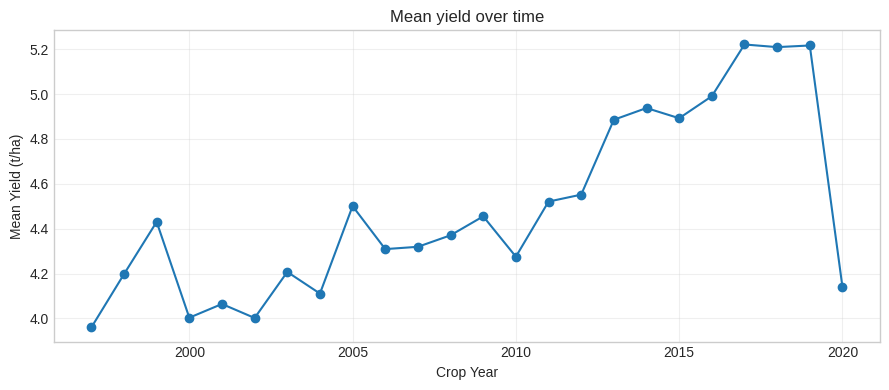

In [ ]:
year_yield = (
    df_model.groupby("Crop_Year")["Yield"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(9, 4))
plt.plot(year_yield.index, year_yield.values, marker="o")
plt.xlabel("Crop Year")
plt.ylabel("Mean Yield (t/ha)")
plt.title("Mean yield over time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Average yield increases gradually from around 4.0 t/ha in the late 1990s to just above 5.2 t/ha after 2015, suggesting a slow but persistent upward trend over time. The final year shows a noticeable drop back towards 4.1 t/ha, which may reflect recent variability or incomplete reporting for the most recent season rather than a structural reversal.

### 4.5 Yield by state (top 15)

I compare average yields across states to capture spatial variation.

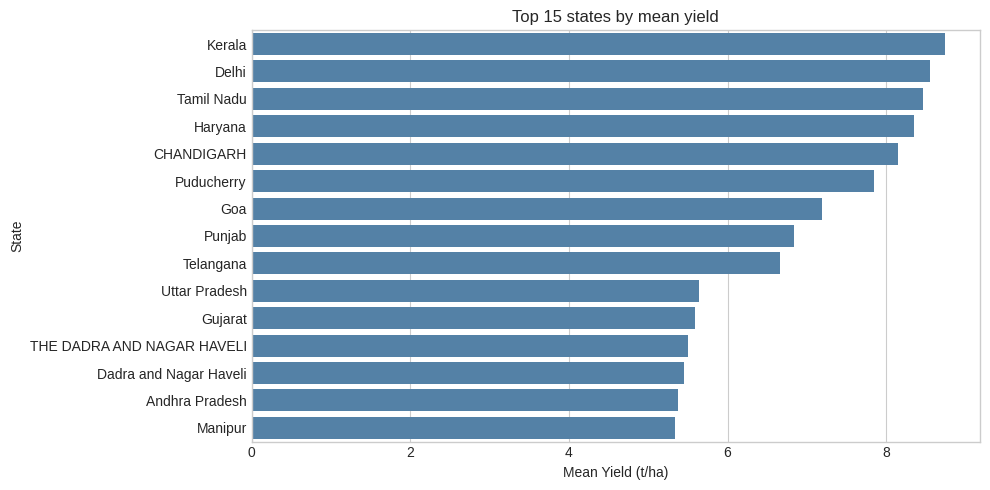

In [ ]:
state_yield = (
    df_model.groupby("State")["Yield"]
    .mean()
    .sort_values(ascending=False)
)

top_n = 15
top_states = state_yield.head(top_n)

plt.figure(figsize=(10, 5))
sns.barplot(
    y=top_states.index,
    x=top_states.values,
    color="steelblue"
)
plt.xlabel("Mean Yield (t/ha)")
plt.ylabel("State")
plt.title(f"Top {top_n} states by mean yield")
plt.tight_layout()
plt.show()

Among the top 15 states and union territories by mean yield, Kerala and Delhi have the highest average yields, followed closely by Tamil Nadu and Haryana. The spread between the top and bottom entries in this list is substantial, confirming strong spatial heterogeneity in typical district yields across India and highlighting State as an important predictor for the modelling stage.

###4.6 Correlation between numeric variables

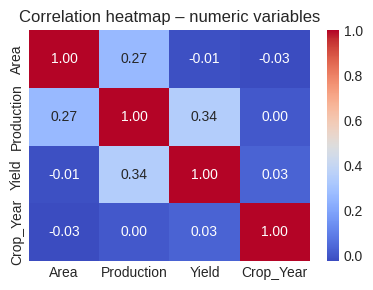

In [ ]:
corr = df_clean[["Area", "Production", "Yield", "Crop_Year"]].corr()

plt.figure(figsize=(4, 3))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap – numeric variables")
plt.tight_layout()
plt.show()

The correlation heatmap shows that Production is moderately positively correlated with Yield (around 0.34), while Area has only a very weak relationship with Yield and a modest positive correlation with Production. Crop_Year is essentially uncorrelated with the other numeric variables, suggesting that most of the temporal trend in yields is captured by categorical or higher‑order structure rather than a simple linear relationship with year.


## 5. Train, validation and test split

I create a temporal split by crop year so that later years are held out for validation and testing.

### 5.1 Split summary

In [ ]:
# Check year range
print("Year range:", df_model["Crop_Year"].min(), "to", df_model["Crop_Year"].max())

# Example split: train 1997–2012, val 2013–2015, test 2016–2019
train_years = list(range(1997, 2013))
val_years   = list(range(2013, 2016))
test_years  = list(range(2016, 2020))

train_df = df_model[df_model["Crop_Year"].isin(train_years)].copy()
val_df   = df_model[df_model["Crop_Year"].isin(val_years)].copy()
test_df  = df_model[df_model["Crop_Year"].isin(test_years)].copy()

print("Train size:", len(train_df))
print("Val size:  ", len(val_df))
print("Test size: ", len(test_df))

Year range: 1997 to 2020
Train size: 217311
Val size:   47036
Test size:  71331


Crop years in the cleaned dataset span 1997 to 2020. The temporal split allocates 217,311 rows to training (1997–2012), 47,036 rows to validation (2013–2015) and 71,331 rows to testing (2016–2019), so that later years act as held‑out sets for model selection and final evaluation.

## 6. Feature encoding and design matrix

I encode categorical variables and assemble numeric feature matrices and target vectors for each split.

6.1 Define feature sets and target

In [ ]:
# Categorical and numeric predictors
cat_cols = ["State", "District", "Crop", "Season"]
num_cols = ["Area", "Crop_Year"]  # Production removed
target_col = "Yield"


# Drop any remaining missing values in features
for df_part, name in [(train_df, "train"), (val_df, "val"), (test_df, "test")]:
    missing = df_part[cat_cols + num_cols].isna().sum()
    print(f"\nMissing feature values in {name} set:")
    print(missing[missing > 0])


Missing feature values in train set:
Series([], dtype: int64)

Missing feature values in val set:
Series([], dtype: int64)

Missing feature values in test set:
Series([], dtype: int64)


All selected feature columns (State, District, Crop, Season, Area and Crop_Year) have no missing values in the train, validation and test splits. The target variable is Yield, modelled using four categorical predictors (State, District, Crop, Season) and two numeric predictors (Area, Crop_Year), with Production deliberately excluded to avoid target leakage.

6.2 Ordinal encoding for categoricals

In [ ]:
# Use the cleaned modelling dataset
df_model = df_clean.copy()

# Year-based split
train_years = list(range(1997, 2013))
val_years   = list(range(2013, 2016))
test_years  = list(range(2016, 2020))

train_df = df_model[df_model["Crop_Year"].isin(train_years)].copy()
val_df   = df_model[df_model["Crop_Year"].isin(val_years)].copy()
test_df  = df_model[df_model["Crop_Year"].isin(test_years)].copy()

print("Train size:", len(train_df))
print("Val size:  ", len(val_df))
print("Test size: ", len(test_df))

Train size: 217311
Val size:   47036
Test size:  71331


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

# Fit on training set categoricals
train_cat = train_df[cat_cols]
val_cat   = val_df[cat_cols]
test_cat  = test_df[cat_cols]

encoder.fit(train_cat)

train_cat_enc = encoder.transform(train_cat)
val_cat_enc   = encoder.transform(val_cat)
test_cat_enc  = encoder.transform(test_cat)

# Numerical parts
train_num = train_df[num_cols].values
val_num   = val_df[num_cols].values
test_num  = test_df[num_cols].values

# Design matrices
train_X = np.hstack([train_cat_enc, train_num])
val_X   = np.hstack([val_cat_enc,   val_num])
test_X  = np.hstack([test_cat_enc,  test_num])

# Targets
train_y = train_df[target_col].values
val_y   = val_df[target_col].values
test_y  = test_df[target_col].values

print("Train X shape:", train_X.shape)
print("Val   X shape:", val_X.shape)
print("Test  X shape:", test_X.shape)

Train X shape: (217311, 6)
Val   X shape: (47036, 6)
Test  X shape: (71331, 6)


Categorical predictors (State, District, Crop, Season) are ordinal‑encoded using codes learned on the training set, with unseen categories in validation and test mapped to a reserved code. After concatenating the four encoded categorical features with the two numeric predictors (Area, Crop_Year), the design matrices have 6 columns with shapes of 217,311 rows for training, 47,036 for validation and 71,331 for testing.

## 7. Modelling – initial models

I first train three baseline models on the encoded features: Ridge regression, Random Forest and HistGradientBoostingRegressor.

A common evaluation helper computes RMSE, MAE and R² on any split, ensuring that all models are compared on the same metrics.

7.1 Helper for evaluation

In [ ]:
from sklearn.linear_model import Ridge
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def compute_metrics(model, X, y):
    preds = model.predict(X)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y, preds)
    r2   = r2_score(y, preds)
    return rmse, mae, r2

7.2 Ridge regression

In [ ]:
print("=== Ridge regression ===")

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(train_X, train_y)

ridge_train = compute_metrics(ridge, train_X, train_y)
ridge_val   = compute_metrics(ridge, val_X,   val_y)
ridge_test  = compute_metrics(ridge, test_X,  test_y)

ridge_results = pd.DataFrame(
    [
        ["Train",      *ridge_train],
        ["Validation", *ridge_val],
        ["Test",       *ridge_test],
    ],
    columns=["Split", "RMSE", "MAE", "R²"]
)

ridge_results

=== Ridge regression ===


,Split,RMSE,MAE,R²
0,Train,11.201007,5.321104,0.112248
1,Validation,12.046547,5.639594,0.098653
2,Test,12.196872,5.675066,0.085493


Ridge regression gives relatively weak performance, with test RMSE around 12.2 t/ha and R² of only 0.09. This indicates that a regularised linear model cannot capture most of the variation in district‑level yields given the available features.


7.3 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

print("=== Random Forest (baseline) ===")

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(train_X, train_y)

rf_train = compute_metrics(rf, train_X, train_y)
rf_val   = compute_metrics(rf, val_X,   val_y)
rf_test  = compute_metrics(rf, test_X,  test_y)

rf_results = pd.DataFrame(
    [
        ["Train",      *rf_train],
        ["Validation", *rf_val],
        ["Test",       *rf_test],
    ],
    columns=["Split", "RMSE", "MAE", "R²"]
)

rf_results

=== Random Forest (baseline) ===


,Split,RMSE,MAE,R²
0,Train,2.112029,0.528897,0.968437
1,Validation,4.234574,1.259271,0.888625
2,Test,5.776000,1.772946,0.794910


The baseline Random Forest substantially improves performance compared with Ridge, achieving test RMSE of about 5.78 t/ha and R² of 0.79. Training error is very low (R² ≈ 0.97), so the model shows signs of overfitting, but validation and test scores remain strong enough to justify using non‑linear tree‑based methods.

7.4 HistGradientBoostingRegressor

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
import pandas as pd

print("=== HistGradientBoostingRegressor ===")

gb = HistGradientBoostingRegressor(
    max_depth=10,
    learning_rate=0.1,
    max_iter=200,
    min_samples_leaf=20,
    random_state=42
)
gb.fit(train_X, train_y)

gb_train = compute_metrics(gb, train_X, train_y)
gb_val   = compute_metrics(gb, val_X,   val_y)
gb_test  = compute_metrics(gb, test_X,  test_y)

gb_results = pd.DataFrame(
    [
        ["Train",      *gb_train],
        ["Validation", *gb_val],
        ["Test",       *gb_test],
    ],
    columns=["Split", "RMSE", "MAE", "R²"]
)

gb_results

=== HistGradientBoostingRegressor ===


,Split,RMSE,MAE,R²
0,Train,2.925494,1.058323,0.939441
1,Validation,4.173178,1.502100,0.891832
2,Test,5.407927,1.873757,0.820216


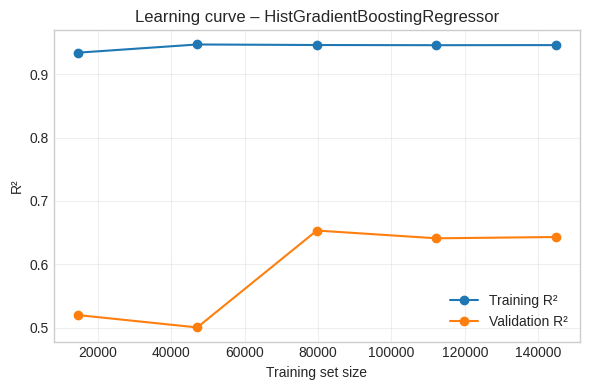

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    gb,  # existing HistGradientBoostingRegressor
    train_X,
    train_y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3,
    scoring="r2",
    n_jobs=-1,
    shuffle=True,
    random_state=42,
)

train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_scores_mean, marker="o", label="Training R²")
plt.plot(train_sizes, val_scores_mean, marker="o", label="Validation R²")
plt.xlabel("Training set size")
plt.ylabel("R²")
plt.title("Learning curve – HistGradientBoostingRegressor")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The HistGradientBoostingRegressor performs slightly better than the Random Forest on the hold‑out test set, with RMSE around 5.41 t/ha and R² of 0.82. The learning curve shows consistently high training R² above 0.93 and validation R² increasing with more data, suggesting some overfitting but also that additional data could further improve generalisation.


## 8. Model refinement and tuning

I refine the tree‑based models to see whether careful tuning or crop‑specific training can improve performance.

8.1 Regularised Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

print("=== Regularised Random Forest ===")

rf2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)
rf2.fit(train_X, train_y)

rf2_train = compute_metrics(rf2, train_X, train_y)
rf2_val   = compute_metrics(rf2, val_X,   val_y)
rf2_test  = compute_metrics(rf2, test_X,  test_y)

rf2_results = pd.DataFrame(
    [
        ["Train",      *rf2_train],
        ["Validation", *rf2_val],
        ["Test",       *rf2_test],
    ],
    columns=["Split", "RMSE", "MAE", "R²"]
)

rf2_results

=== Regularised Random Forest ===


,Split,RMSE,MAE,R²
0,Train,2.574817,0.685233,0.953089
1,Validation,4.347072,1.303316,0.882629
2,Test,5.845450,1.801532,0.789948


The regularised Random Forest slightly reduces overfitting compared with the baseline RF, with training R² falling from about 0.97 to 0.95 and a small increase in training RMSE. Test performance (RMSE ≈ 5.85 t/ha, R² ≈ 0.79) is very similar to the baseline RF and still clearly below the HistGradientBoosting model, so this more constrained configuration does not yield a better trade‑off between bias and variance.


8.2 High‑yield crops Random Forest

In [ ]:
import numpy as np
import pandas as pd

high_yield_crops = ["Sugarcane", "Coconut", "Banana", "Tapioca", "Potato", "Onion"]

# Filter each split to high-yield crops
train_high = train_df[train_df["Crop"].isin(high_yield_crops)].copy()
val_high   = val_df[val_df["Crop"].isin(high_yield_crops)].copy()
test_high  = test_df[test_df["Crop"].isin(high_yield_crops)].copy()

print("High-yield subset sizes:", train_high.shape, val_high.shape, test_high.shape)

# Rebuild X,y for the subset using the same encoder and feature lists
train_high_cat = encoder.transform(train_high[cat_cols])
val_high_cat   = encoder.transform(val_high[cat_cols])
test_high_cat  = encoder.transform(test_high[cat_cols])

train_high_num = train_high[num_cols].values
val_high_num   = val_high[num_cols].values
test_high_num  = test_high[num_cols].values

train_high_X = np.hstack([train_high_cat, train_high_num])
val_high_X   = np.hstack([val_high_cat,   val_high_num])
test_high_X  = np.hstack([test_high_cat,  test_high_num])

train_high_y = train_high["Yield"].values
val_high_y   = val_high["Yield"].values
test_high_y  = test_high["Yield"].values

# Train a Random Forest only on high-yield crops
rf_high = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf_high.fit(train_high_X, train_high_y)

high_rf_train = compute_metrics(rf_high, train_high_X, train_high_y)
high_rf_val   = compute_metrics(rf_high, val_high_X,   val_high_y)
high_rf_test  = compute_metrics(rf_high, test_high_X,  test_high_y)

rf_high_results = pd.DataFrame(
    [
        ["Train (high-yield)",      *high_rf_train],
        ["Validation (high-yield)", *high_rf_val],
        ["Test (high-yield)",       *high_rf_test],
    ],
    columns=["Split", "RMSE", "MAE", "R²"]
)

rf_high_results

High-yield subset sizes: (24521, 8) (5524, 8) (8302, 8)


,Split,RMSE,MAE,R²
0,Train (high-yield),5.937538,3.001489,0.947006
1,Validation (high-yield),10.296042,5.758533,0.850894
2,Test (high-yield),13.390654,8.029658,0.736384


The crop‑specific Random Forest trained only on high‑yield crops achieves strong in‑sample performance (train RMSE ≈ 5.94 t/ha, R² ≈ 0.95) but substantially larger errors on the high‑yield test subset (RMSE ≈ 13.39 t/ha, R² ≈ 0.74). This indicates that, in this configuration, specialising on high‑yield crops does not outperform the best global models and may overfit the smaller high‑yield subset.


8.3 Hyperparameter tuning for one model

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "max_depth": [5, 7, 9, 11],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_iter": [100, 200, 300],
    "min_samples_leaf": [10, 20, 50],
}

gb_base = HistGradientBoostingRegressor(random_state=42)

gb_search = RandomizedSearchCV(
    gb_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

gb_search.fit(train_X, train_y)
print("Best parameters:", gb_search.best_params_)

gb_best = gb_search.best_estimator_

gb_base_test = compute_metrics(gb, test_X, test_y)       # baseline HGB
gb_best_test = compute_metrics(gb_best, test_X, test_y)  # tuned HGB

gb_tune_df = pd.DataFrame(
    [
        ["HistGB (baseline)", *gb_base_test],
        ["HistGB (tuned)",    *gb_best_test],
    ],
    columns=["Model", "RMSE", "MAE", "R²"]
)
gb_tune_df

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'min_samples_leaf': 10, 'max_iter': 100, 'max_depth': 5, 'learning_rate': 0.05}


,Model,RMSE,MAE,R²
0,HistGB (baseline),5.407927,1.873757,0.820216
1,HistGB (tuned),5.997085,2.220123,0.778909


A randomised search over max_depth, learning_rate, max_iter and min_samples_leaf was run for the HistGradientBoostingRegressor using 3‑fold cross‑validation and RMSE as the scoring metric. The best configuration found (shallower trees and lower learning rate: max_depth = 5, learning_rate = 0.05, max_iter = 100, min_samples_leaf = 10) yields worse test performance than the baseline (RMSE 5.99 vs 5.41 t/ha, R² 0.78 vs 0.82), suggesting that this level of regularisation reduces overfitting but also harms predictive accuracy.

The baseline configuration is therefore retained as the main gradient‑boosting model for the final comparison, while the tuned model serves to demonstrate the effect of hyperparameter regularisation.

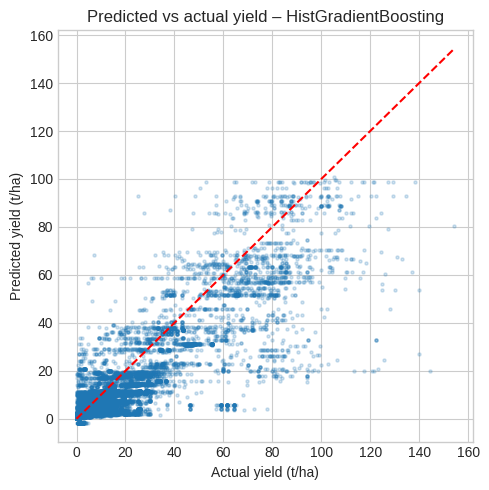

In [ ]:
best_model = gb_best  # tuned HistGradientBoosting
best_preds = best_model.predict(test_X)

plt.figure(figsize=(5, 5))
plt.scatter(test_y, best_preds, alpha=0.2, s=5)
plt.xlabel("Actual yield (t/ha)")
plt.ylabel("Predicted yield (t/ha)")
plt.title("Predicted vs actual yield – HistGradientBoosting")
plt.plot(
    [test_y.min(), test_y.max()],
    [test_y.min(), test_y.max()],
    color="red",
    linestyle="--",
)
plt.tight_layout()
plt.show()

8.4 compare global RF vs high‑yield RF on the same subset

In [ ]:
# Compare the baseline global RF to the crop-specific RF on the same high-yield test subset
global_rf_on_high = compute_metrics(rf, test_high_X, test_high_y)

comparison_high = pd.DataFrame(
    [
        ["Global RF (high-yield test)", *global_rf_on_high],
        ["High-yield RF (high-yield test)", *high_rf_test],
    ],
    columns=["Model / Split", "RMSE", "MAE", "R²"]
)

comparison_high

,Model / Split,RMSE,MAE,R²
0,Global RF (high-yield test),15.753889,8.859693,0.635125
1,High-yield RF (high-yield test),13.390654,8.029658,0.736384


On the shared high‑yield test subset, the crop‑specific Random Forest outperforms the global Random Forest (R² ≈ 0.74 vs 0.64 and RMSE ≈ 13.39 vs 15.75 t/ha), indicating some benefit from specialising the model on high‑yield crops. However, both models still have sizeable errors on these extreme observations, so improving prediction for the very highest yields remains challenging.

## 9. Final model comparison

In [ ]:
import pandas as pd

# Test metrics from earlier sections
ridge_test_rmse, ridge_test_mae, ridge_test_r2 = ridge_test
rf_test_rmse,    rf_test_mae,    rf_test_r2    = rf_test
gb_test_rmse,    gb_test_mae,    gb_test_r2    = gb_test
rf2_test_rmse,   rf2_test_mae,   rf2_test_r2   = rf2_test

comparison_rows = [
    ["Ridge regression",              ridge_test_rmse, ridge_test_mae, ridge_test_r2],
    ["Random Forest (baseline)",      rf_test_rmse,    rf_test_mae,    rf_test_r2],
    ["HistGradientBoostingRegressor", gb_test_rmse,    gb_test_mae,    gb_test_r2],
    ["Regularised Random Forest",     rf2_test_rmse,   rf2_test_mae,   rf2_test_r2],
]

comparison_df = pd.DataFrame(
    comparison_rows,
    columns=["Model", "Test RMSE", "Test MAE", "Test R²"]
).sort_values("Test RMSE")

comparison_df

,Model,Test RMSE,Test MAE,Test R²
2,HistGradientBoostingRegressor,5.407927,1.873757,0.820216
1,Random Forest (baseline),5.776000,1.772946,0.794910
3,Regularised Random Forest,5.845450,1.801532,0.789948
0,Ridge regression,12.196872,5.675066,0.085493


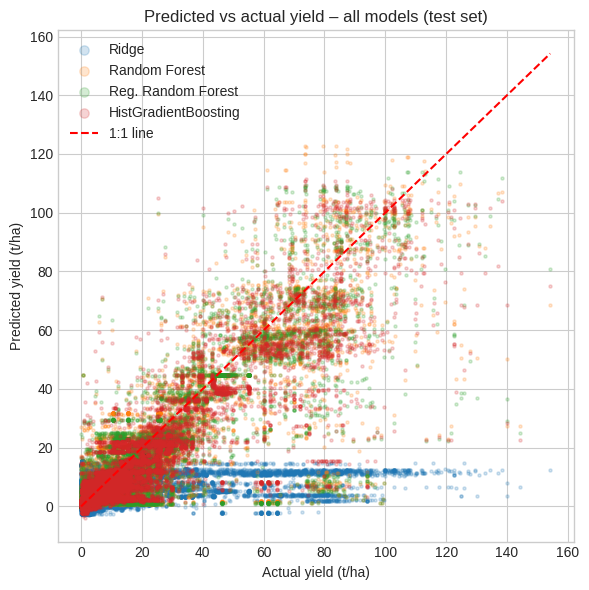

In [ ]:
y_test = test_y  # this already exists

ridge_pred   = ridge.predict(test_X)
rf_pred      = rf.predict(test_X)
rf_reg_pred  = rf2.predict(test_X)   # note: rf2 is your regularised RF
hgb_pred     = gb.predict(test_X)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, ridge_pred,  alpha=0.2, s=5, label="Ridge")
plt.scatter(y_test, rf_pred,     alpha=0.2, s=5, label="Random Forest")
plt.scatter(y_test, rf_reg_pred, alpha=0.2, s=5, label="Reg. Random Forest")
plt.scatter(y_test, hgb_pred,    alpha=0.2, s=5, label="HistGradientBoosting")

min_y, max_y = y_test.min(), y_test.max()
plt.plot([min_y, max_y], [min_y, max_y], "r--", label="1:1 line")

plt.xlabel("Actual yield (t/ha)")
plt.ylabel("Predicted yield (t/ha)")
plt.title("Predicted vs actual yield – all models (test set)")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

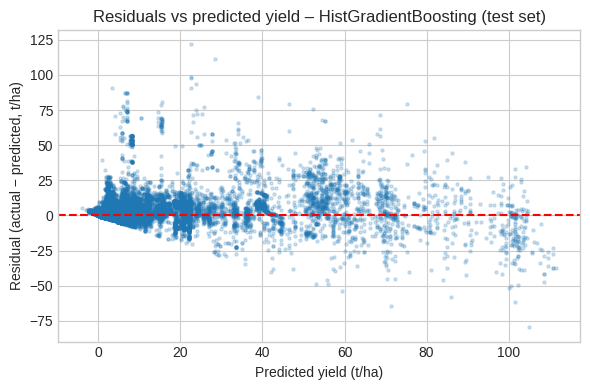

In [ ]:
gb_preds = gb.predict(test_X)
residuals = test_y - gb_preds

plt.figure(figsize=(6, 4))
plt.scatter(gb_preds, residuals, alpha=0.2, s=5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted yield (t/ha)")
plt.ylabel("Residual (actual − predicted, t/ha)")
plt.title("Residuals vs predicted yield – HistGradientBoosting (test set)")
plt.tight_layout()
plt.savefig("fig_gb_residuals_vs_pred.png", dpi=300, bbox_inches="tight")
plt.show()

### Overall conclusion on model performance

The HistGradientBoostingRegressor performs best overall, with the lowest test RMSE (≈ 5.41 t/ha) and highest R² (≈ 0.82), indicating that it captures non‑linear relationships and interactions in the data most effectively. The baseline Random Forest is the second‑best model (test RMSE ≈ 5.78 t/ha, R² ≈ 0.79), confirming that tree‑based ensembles are well suited to this problem, although boosting provides a modest accuracy gain. The regularised Random Forest offers slightly less overfitting than the baseline RF but marginally worse test performance, while Ridge regression performs very poorly (test R² ≈ 0.09), showing that a simple linear model cannot explain the complex spatial, temporal and crop‑level patterns in district‑level yields.


## 10. Feature importance

I first inspect feature importance with the Random Forest model, because its tree‑based importances are easy to compute and interpret. Since the Random Forest performs close to the best model, its ranking gives a clear and representative view of which predictors matter most before I confirm the pattern with permutation importance on HistGradientBoostingRegressor.

10.1 Random Forest feature importances

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature names in the same order as train_X columns
feature_names = cat_cols + num_cols

rf_importances = pd.Series(rf.feature_importances_, index=feature_names)
rf_importances = rf_importances.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=rf_importances.values, y=rf_importances.index, color="steelblue")
plt.xlabel("Importance (Gini importance)")
plt.ylabel("Feature")
plt.title("Random Forest feature importances")
plt.tight_layout()
plt.show()

rf_importances

Crop is by far the most important predictor in the Random Forest, followed by State and Season, with Area contributing a smaller but still non‑negligible effect. Crop_Year and District have much lower importances, suggesting that broad crop type and spatial location dominate the model’s yield decisions, while simple time trends and fine‑grained district identity add only modest additional information.


### 10.2 Feature importance for the best model

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature names in the same order as train_X columns
feature_names = cat_cols + num_cols

print("Computing permutation importance for HistGradientBoostingRegressor...")
perm_result = permutation_importance(
    gb,
    X=test_X,
    y=test_y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

gb_importances = pd.Series(perm_result.importances_mean, index=feature_names)
gb_importances = gb_importances.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=gb_importances.values, y=gb_importances.index, color="steelblue")
plt.xlabel("Decrease in R² when shuffled")
plt.ylabel("Feature")
plt.title("Permutation feature importance (HistGradientBoostingRegressor)")
plt.tight_layout()
plt.show()

gb_importances

Permutation importance for the HistGradientBoostingRegressor again highlights Crop as the dominant feature, with Season and State also causing noticeable drops in R² when shuffled. Area has a much smaller effect, and shuffling District or Crop_Year barely changes performance, indicating that most of the predictive signal is carried by crop type and broad seasonal and spatial patterns rather than fine‑grained district identity or simple year effects.


## 11. Notebook summary

The APY dataset was cleaned by removing records with missing Crop, non‑positive yields and extreme yield outliers, and then split into temporal train, validation and test sets using crop years 1997–2012 for training, 2013–2015 for validation and 2016–2019 for testing. Exploratory analysis showed strong right‑skew in the raw Area, Production and Yield variables, clear seasonal and spatial differences in mean yields, and a gradual increase in average yield over time. Using encoded categorical and numeric features (State, District, Crop, Season, Area and Crop_Year, with Production excluded to avoid target leakage), Ridge regression, Random Forest and HistGradientBoostingRegressor models were trained, with HistGradientBoostingRegressor achieving the best test performance (RMSE ≈ 5.41 t/ha, R² ≈ 0.82). Further regularisation and a crop‑specific Random Forest for high‑yield crops did not outperform the boosted model, and feature‑importance analysis for both Random Forest and HistGradientBoosting highlighted Crop as the dominant predictor, followed by Season and State, with Area contributing modestly and District and Crop_Year adding little additional information.
